# Genomics Laboratory

## Solutions Notebook

This notebook contains exercises for the Genomics laboratory session. Complete each exercise by following the step-by-step instructions and filling in the code stubs.

**Learning Objectives:**
- Retrieve genomic data from public databases using REST APIs
- Analyze DNA sequences and compute basic statistics
- Find Transcription-factor binging sites using knonwn binding motifs
- Integrate multi-omics data (genomics, epigenomics)

**Instructions:**
- Read each exercise description carefully
- Follow the step-by-step instructions
- Fill in the code stubs marked with `# TODO:` comments
- Run each cell and verify your results
- Ask for help if you get stuck!

---

## Laboratory Overview

1. **Exercise 1: Calling motifs**
   - Find the information about the CTCF binding motif in human (_Homo sapiens_).
   - Download and inspect the Jaspar files.
   - Download the sequence for human chromosome 17 (GRCh38 reference genome) from [Ensembl ftp](https://ftp.ensembl.org/pub/release-115/fasta/homo_sapiens/dna/).
   - Scan the sequence for motif matches, obtaining the score. Plot the score distribution.
   - Select a set of significant motifs. Save their locations to a .bed file along with sequence information.

1. **Exercise 2: Validation using ChIP-seq data**
   - Find the ChIP-seq signal data for the GM12878 CTCF ChIP-seq (Encode accession: ENCFF017XLW).
   - Use the genome browser to preview the signal.
   - Download the significant peaks (we will skip _peak calling_).
   - How well do the identified motifs correspond to the actual ChIP-seq peaks?
   
      - Map peaks to motifs (use `pyranges`).
      - How many motifs have peaks inside?
      - How many peaks are outside motifs?
      - Show counts and ratios of mapped and unmapped peaks and motifs:
      - Plot motif score vs peak strength for successfull mappings
   
   - Prepare and save a "gold" .bed file with significant motifs that also have strong peaks inside.
   

In [3]:
# Import required libraries
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import biotite
import re
import os

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')

# Set up output directory
output_dir = "lab_outputs"
os.makedirs(output_dir, exist_ok=True)

print("✓ Libraries imported successfully")


✓ Libraries imported successfully


## Exercise 1: Calling Motifs

**Goal:** Teach motif databases usage, PWM/PSSM handling, motif scanning, and genomic interval handling.

**Background:**
Transcription factors bind DNA at specific sequence patterns called *motifs*. These motifs are often represented as Position Weight Matrices (PWMs), which describe nucleotide preferences at each position. Databases like JASPAR provide curated motif collections, including the well-known insulator protein CTCF binding motif in humans.

---

### **Task List:**

1. **Retrieve information about the CTCF motif:**

   * Look up the CTCF binding motif for _Homo Sapiens_ in JASPAR (use the one with ID ending with `39.1`).
   * Identify consensus sequence and motif length

2. **Download and inspect motif files:**

   * Download the motif in JASPAR format (PFM)
   * Load the file into Python
   * Convert the Position Frequency Matrix (PFM) into:

     * Position Weight Matrix (PWM)
     * Position-Specific Scoring Matrix (PSSM)

3. **Scan a DNA sequence for motif occurrences:**

   * Use ~3Mb sequence around the BRCA1 gene (chr17: 42,000,000-45,000,000)
   * Compute a motif score at each position using the PSSM.
   * Remember the reverse strand!

4. **Plot motif score distribution:**

   * Create a histogram / KDE plot of motif scores.
   * Define a threshold (e.g., 0.999 quantile)
   * Plot score vs. sequence position on small example region.

5. **Select significant motif hits:**

   * Filter motif matches above threshold
   * Store in a Pandas DataFrame:
     * Start and end positions
     * Strand (+/-)
     * Motif score
     * Matched sequence

6. **Export motif locations to BED format:**

   * Create a `.bed` file with the following columns:

     * Chromosome (or sequence ID)
     * Start position
     * End position
     * Motif name (e.g., CTCF)
     * Score
     * Strand
     * Matched sequence (optional)

---

### **Key Concepts:**

* Transcription factor binding motifs.
* Position Frequency Matrix (PFM), PWM, and PSSM.
* Biological interpretation of motif hits, source of PFM data.
* Score distributions and thresholding.
* Genomic interval formats (BED).
* ChIP-seq experiment: signal and peaks.

In [11]:
import biotite.sequence.io.fasta
import gzip

# Open gzipped FASTA file in text mode
with gzip.open("./lab_outputs/Homo_sapiens.GRCh38.dna.chromosome.17.fa.gz", "rt") as f:
    fasta_file = biotite.sequence.io.fasta.FastaFile.read(f)

# Extract sequences
for header, full_sequence in fasta_file.items():
    print(header)
    print(full_sequence[:50])


REGION = (42_000_000, 45_000_000)

def get_region_slice(region):
    return slice(region[0] - REGION[0], region[1] - REGION[0])

sequence = full_sequence[REGION[0]:REGION[1]]
sequence[:50]

17 dna:chromosome chromosome:GRCh38:17:1:83257441:1 REF
NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN


'TAGAGACAGGGTTTCGTCATGTTGGCCAGAGTGGTCTGAAACCCCTGATC'

In [12]:
import requests

def fetch_pfm_jaspar(motif_id):
    """
    Fetch the Position Frequency Matrix (PFM) matrix from JASPAR database.
    
    Parameters:
    - motif_id (str): id of the motif in JASPAR database.
    
    Returns:
    - dict: dictionary with keys 'A', 'C', 'G', 'T' and lists of frequencies
    """
    url = f"https://jaspar.elixir.no/api/v1/matrix/{motif_id.upper()}/?format=json"
    response = requests.get(url)
    
    if not response.ok:
        raise Exception(f"Failed to fetch {motif_id} from JASPAR")
    
    data = response.json()
    pfm = data.get("pfm", None)
    
    return pfm

ctcf_motif_id = 'MA0139.1'
ctcf_jaspar_pfm = fetch_pfm_jaspar(ctcf_motif_id)
print(f"✓ Fetched PFM for motif {ctcf_motif_id} from JASPAR")
print("PFM Matrix:")
for base, freqs in ctcf_jaspar_pfm.items():
    print(f"{base}: {freqs}")

✓ Fetched PFM for motif MA0139.1 from JASPAR
PFM Matrix:
A: [87.0, 167.0, 281.0, 56.0, 8.0, 744.0, 40.0, 107.0, 851.0, 5.0, 333.0, 54.0, 12.0, 56.0, 104.0, 372.0, 82.0, 117.0, 402.0]
C: [291.0, 145.0, 49.0, 800.0, 903.0, 13.0, 528.0, 433.0, 11.0, 0.0, 3.0, 12.0, 0.0, 8.0, 733.0, 13.0, 482.0, 322.0, 181.0]
G: [76.0, 414.0, 449.0, 21.0, 0.0, 65.0, 334.0, 48.0, 32.0, 903.0, 566.0, 504.0, 890.0, 775.0, 5.0, 507.0, 307.0, 73.0, 266.0]
T: [459.0, 187.0, 134.0, 36.0, 2.0, 91.0, 11.0, 324.0, 18.0, 3.0, 9.0, 341.0, 8.0, 71.0, 67.0, 17.0, 37.0, 396.0, 59.0]


In [14]:
def pfm_to_numpy(pfm_dict):
    """
    Convert a PFM dictionary to a numpy array.
    
    Parameters:
    - pfm_dict (dict): dictionary with keys 'A', 'C', 'G', 'T' and lists of frequencies.
    
    Returns:
    - numpy.ndarray: 2D array with shape (4, motif_length) where rows correspond to A, C, G, T.
    """
    return np.vstack([pfm_dict[base] for base in ['A', 'C', 'G', 'T']]).astype(int)

ctcf_pfm = pfm_to_numpy(ctcf_jaspar_pfm)
ctcf_pfm[:, :6]

array([[ 87, 167, 281,  56,   8, 744],
       [291, 145,  49, 800, 903,  13],
       [ 76, 414, 449,  21,   0,  65],
       [459, 187, 134,  36,   2,  91]])

In [15]:
def pfm_to_pwm(pfm, pseudocount=1e-6):
    """
    Convert Position Frequency Matrix to Position Weight Matrix.

    HINT:
    - Add pseudocounts to each element to avoid division by zero
    - Normalize each column so that probabilities sum to 1    
    """
    pwm = None

    # TODO:
    # 1. Convert counts to probabilities per nucleotide base (column).
    # 2. Return as a numpy array of the same shape as pfm.

    pwm = pfm + pseudocount  # Add pseudocounts
    column_sums = pwm.sum(axis=0)  # Sum of each column
    pwm = pwm / column_sums  # Normalize columns to sum to 1

    return pwm

ctcf_pwm = pfm_to_pwm(ctcf_pfm)
print("PWM as numpy array:")
np.round(ctcf_pwm[:, :6], 3)

PWM as numpy array:


array([[0.095, 0.183, 0.308, 0.061, 0.009, 0.815],
       [0.319, 0.159, 0.054, 0.876, 0.989, 0.014],
       [0.083, 0.453, 0.492, 0.023, 0.   , 0.071],
       [0.503, 0.205, 0.147, 0.039, 0.002, 0.1  ]])

In [16]:
def pwm_to_pssm(pwm, background=0.25):
    """
    Convert PWM to PSSM using log2 odds.

    HINT:
    - PSSM = log2(pwm / background)
    - Background is typically 0.25 for each nucleotide
    """
    pssm = None

    # TODO:
    # 1. Compute log2 odds for each value
    # 2. Return as a numpy array of the same shape as pwm.

    pssm = np.log2(pwm / background)

    return pssm


ctcf_pssm = pwm_to_pssm(ctcf_pwm)
print("PSSM as numpy array:")
print(np.round(ctcf_pfm[:, :6], 2))
print(np.round(ctcf_pwm[:, :6], 2))
np.round(ctcf_pssm[:, :6], 2)

PSSM as numpy array:
[[ 87 167 281  56   8 744]
 [291 145  49 800 903  13]
 [ 76 414 449  21   0  65]
 [459 187 134  36   2  91]]
[[0.1  0.18 0.31 0.06 0.01 0.81]
 [0.32 0.16 0.05 0.88 0.99 0.01]
 [0.08 0.45 0.49 0.02 0.   0.07]
 [0.5  0.2  0.15 0.04 0.   0.1 ]]


array([[ -1.39,  -0.45,   0.3 ,  -2.03,  -4.83,   1.7 ],
       [  0.35,  -0.65,  -2.22,   1.81,   1.98,  -4.13],
       [ -1.59,   0.86,   0.98,  -3.44, -27.77,  -1.81],
       [  1.01,  -0.29,  -0.77,  -2.66,  -6.83,  -1.33]])

In [24]:
BASE_TO_PSSM_ROW = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

def single_base_scores(sequence, pssm):
    """
    Return a numpy array of scores for each position in sequence.
    """
    # HINT: You can implement this function first, to make the second one easier
    assert len(sequence) == pssm.shape[1]
    return np.array([pssm[BASE_TO_PSSM_ROW[base], i] for i, base in enumerate(sequence)])

def scan_sequence(sequence, pssm):
    """
    Scan a DNA sequence with a PSSM.

    Parameters:
        sequence (str): DNA sequence
        pssm (matrix): Position-specific scoring matrix

    Returns:
        Numpy vector of scores for each position in the sequence where the motif can fit.
    """
    n_bases = 4
    assert pssm.shape[0] == n_bases, "PSSM should have 4 rows corresponding to A, C, G, T"    
    seq_length = len(sequence)
    motif_length = pssm.shape[1]

    # HINT:
    # - Use numpy for efficient matrix operations
    # - Create the numpy array encoding for the sequence     
    # (In my solution I use some more advanced numpy functions, that should be more efficient)
    sequence_onehot = np.zeros((n_bases, seq_length), dtype=int)
    for i, base in enumerate(sequence):
        j = BASE_TO_PSSM_ROW.get(base, -1)
        if j != -1:
            sequence_onehot[j, i] = 1

    scores = np.zeros(seq_length - motif_length + 1)
    for i in range(n_bases):       
        base_scores = np.convolve(sequence_onehot[i, :], pssm[i, ::-1], mode='valid')
        scores += base_scores
    # scores = np.zeros(seq_length - motif_length + 1)
    # for i in range(len(scores)):
    #     s = single_base_scores(sequence[i:i + motif_length], pssm)
    #     scores[i] = s.sum()
        
    return scores

print('Sanity check:')
most_likely_seq = "TGGCCACCAGGGGGCGCTA"
print("Most likely seq. score:", single_base_scores(most_likely_seq, ctcf_pssm).sum())  # ~26.1
print("Some example scores:", scan_sequence('AA' + most_likely_seq + 'GG', ctcf_pssm))  # ~[-29.4, -21.3, 26.1, -23.3, -22.5]

print('Actual scores for the region (forward strand):')
pos_scores_fwd = scan_sequence(sequence, ctcf_pssm)
print(np.round(pos_scores_fwd[:6], 2))

Sanity check:
Most likely seq. score: 26.120319030305527
Some example scores: [-69.7660106  -22.20742731  26.12031903 -24.21443055 -42.70575332]
Actual scores for the region (forward strand):
[ -30.34  -43.05  -46.58  -29.09  -65.05 -100.14]


In [25]:
# Now, we must alse match the reverse strand!
# Easiest way - transform PSSM:
# 1. Switch each base (row) with its complement (A<->T, G<->C)
# 2. Reverse the order
# ...or you can transform the sequence using e.g. biotite/Biopython helper functions
ctcf_pssm_revcomp = ctcf_pssm[[3, 2, 1, 0], ::-1]

print('Sanity check:')
print('Base sequence:', most_likely_seq)
most_likely_seq_comp = biotite.sequence.NucleotideSequence(most_likely_seq).complement()
print('Complement sequence:', most_likely_seq_comp)
most_likely_seq_revcomp = most_likely_seq_comp.reverse()
print('Reverse complement:', most_likely_seq_revcomp)
print(single_base_scores(most_likely_seq_revcomp, ctcf_pssm_revcomp).sum())  # ~26.1

print('Actual scores for the region (reverse strand):')
pos_scores_rev = scan_sequence(sequence, ctcf_pssm_revcomp)
print(np.round(pos_scores_rev[:6], 2))
ctcf_pssm_revcomp

Sanity check:
Base sequence: TGGCCACCAGGGGGCGCTA
Complement sequence: ACCGGTGGTCCCCCGCGAT
Reverse complement: TAGCGCCCCCTGGTGGCCA
26.120319030305527
Actual scores for the region (reverse strand):
[-62.54 -55.53 -65.05 -76.07 -59.92 -26.32]


array([[ -1.94390542,   0.80280813,  -2.61709509,  -3.74067356,
         -1.76204728,  -1.6799756 ,  -4.82972256,   0.58232068,
         -4.66138209,  -6.24634427,  -3.66296494,   0.50695999,
         -4.37503931,  -1.3266764 ,  -6.83447033,  -2.66454601,
         -0.76838186,  -0.28757659,   1.00787929],
       [  0.22873395,  -1.63672392,   0.43554636,   1.15770545,
         -5.50620811,   1.76832976,   1.96793879,   1.14597268,
          1.313351  ,   1.98727493,  -2.83288998,  -2.24792749,
          0.54923324,  -1.81210322, -27.76603963,  -3.44215356,
          0.97610058,   0.8590159 ,  -1.58654352],
       [ -0.3267026 ,   0.50436839,   1.08634085,  -4.12769666,
          1.6895329 ,  -4.82972256, -27.76129131,  -4.24634463,
         -6.24634427, -27.76287582,  -4.37345827,   0.9253332 ,
          1.20992307,  -4.13403123,   1.98411112,   1.80938514,
         -2.21976118,  -0.65456196,   0.35040429],
       [  0.8245032 ,  -0.95618376,  -1.46899647,   0.71102232,
         -1.127

quantile: 0.999 cutoff: 3.390, no. potential binding sites above this score: 6000


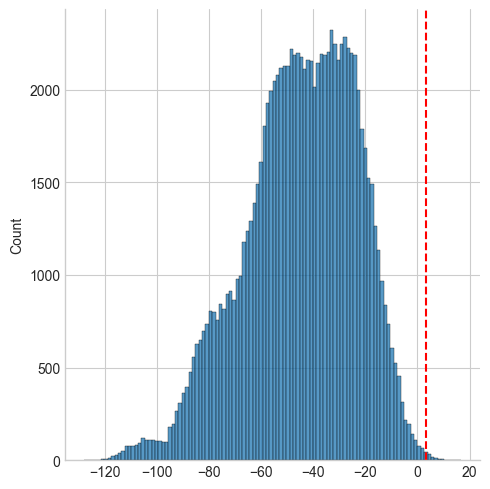

In [26]:
# TODO: print the scores distribution using seaborn
q = 0.999
all_scores = np.concatenate([pos_scores_fwd, pos_scores_rev])
cutoff = np.quantile(all_scores, q)
sns.displot(np.random.choice(all_scores, 100_000))  # Only use a subsample for KDE -> faster
plt.axvline(cutoff, color='red', linestyle='--')
print(f"quantile: {q} cutoff: {cutoff:.3f}, no. potential binding sites above this score: {np.sum(all_scores > cutoff)}")

In [27]:
def get_hits_as_df(sequence, region_offset, scores_fwd, scores_rev, cutoff, motif_len):
    """
    Extract hits above cutoff, to a Pandas DataFrame with columns:
    start - start of the match (in global coordinates)
    end - end of the match (in global coordinates)
    strand - "+" (froward) or "-" (reverese)
    score - 
    sequence - 
    """
    hits = []
    assert scores_fwd.shape == scores_rev.shape
    for i in range(len(scores_fwd)):
        if scores_fwd[i] > cutoff:
            matched = sequence[i:i + motif_len]
            hits.append((i + region_offset, i + region_offset + motif_len, '+', scores_fwd[i], matched))
        if scores_rev[i] > cutoff:
            matched = str(biotite.sequence.NucleotideSequence(sequence[i:i + motif_len]).complement())
            hits.append((i + region_offset, i + region_offset + motif_len, '-', scores_rev[i], matched))
    return pd.DataFrame.from_records(hits, columns=['start', 'end', 'strand', 'score', 'sequence'])

hits_df = get_hits_as_df(sequence, REGION[0], pos_scores_fwd, pos_scores_rev, cutoff, ctcf_pssm.shape[1])
hits_df

,start,end,strand,score,sequence
0,42000724,42000743,+,10.436556,GGACCAAAAGGAGGTGCTA
1,42001028,42001047,-,3.599664,ATTAAAGTGGAGGACTTTT
2,42003364,42003383,+,4.866674,AGACCAGTCGAGGAAAGAG
3,42003595,42003614,-,5.006484,CTTCCGTTAGACCACCACC
4,42004307,42004326,+,4.963035,CCTCCAACAGAGGAAGAGC
...,...,...,...,...,...
5995,44998152,44998171,-,7.160130,GGGAAGGTGGACGATCGAC
5996,44998393,44998412,-,6.774611,TCGGTCGGGGAGGACCTGT
5997,44998659,44998678,+,5.407111,GTCCCAGCAGGAGGCTAGA
5998,44998772,44998791,-,5.105429,AGGAAGGGTGACCCCCACC


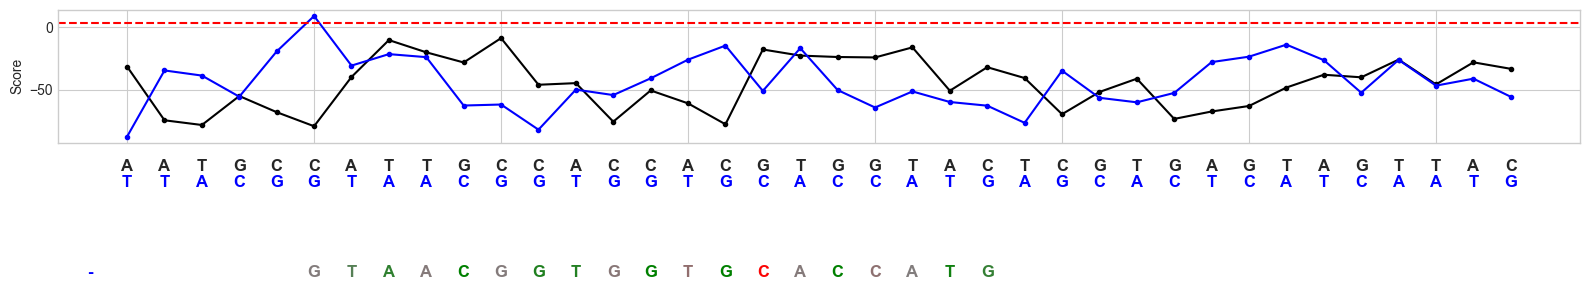

In [28]:
def plot_score_with_sequence(sequence, region_offset, scores_fwd, scores_rev, cutoff=None, pssm=None, hits_df=None, fontsize=12):
    x = range(len(sequence))
    sequence_comp = biotite.sequence.NucleotideSequence(sequence).complement()
    font_kws = {'ha': 'center', 'va': 'center', 'fontsize': fontsize, 'fontweight': 'bold'}

    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1,
        figsize=(16, 3),
        sharex=True,
        gridspec_kw={'height_ratios': [4, 1, 2]}
    )

    ax1.plot(x, scores_fwd, marker='.', color='black')
    ax1.plot(x, scores_rev, marker='.', color='blue')
    if cutoff is not None:
        ax1.axhline(cutoff, color='red', linestyle='--');         
    ax1.set_ylabel("Score")

    ax2.set_ylim(0, 2)
    ax2.axis('off')
    for i, (base, cbase) in enumerate(zip(sequence, sequence_comp)):
        ax2.text(i, 1.5, base, **font_kws) 
        ax2.text(i, 0.5, cbase, color='blue', **font_kws)

    ax3.set_ylim(0, 1)
    ax3.axis('off')
    if hits_df is not None:
        cmap = matplotlib.colors.LinearSegmentedColormap.from_list("red_gray_green", ["red", "gray", "green"])
        norm = matplotlib.colors.TwoSlopeNorm(vmin=pssm.min(), vcenter=0, vmax=pssm.max())
        hits_df = hits_df[(hits_df.start >= region_offset) & (hits_df.end <= region_offset + len(sequence))]
        for i, (start, end, strand, score, hit_seq) in enumerate(hits_df.itertuples(index=False)):
            hit_scores = single_base_scores(hit_seq, pssm)            
            hit_scores = hit_scores - pssm.min() / (pssm.max() - pssm.min())
            y = 0.5 * i
            ax3.text(-1, y, strand, color='black' if strand == '+' else 'blue', **font_kws)
            for j, base in enumerate(hit_seq):
                ax3.text(
                    start - region_offset + j, y, base,
                    color=cmap(norm(hit_scores[j])), **font_kws
                )

    plt.tight_layout()

small_region = (43_084_744, 43_084_782)
plot_score_with_sequence(
    sequence[get_region_slice(small_region)],
    small_region[0],
    pos_scores_fwd[get_region_slice(small_region)],
    pos_scores_rev[get_region_slice(small_region)],
    cutoff=cutoff, pssm=ctcf_pssm, hits_df=hits_df
)

# You can compare this to the consensus sequence for CTCF motif: RCCASNAGRKGGCRS
# Translated to regex (this corresponds to indices: 2-17 in our sequence):
# pattern = r"[AG]CCA[GC][ACGT]AG[AG][GT]GGC[AG][GC]"

In [29]:
def save_to_bed(hits_df, output_file):
    """
    Save motif hits to BED format, with columns:
    chromosome, start, end, name, score, strand, sequence
    """    
    # TODO: use pandas to write the file
    # BED format is a tab-separated text format.
    # It has 3 mandatory columns: chromosome, start, end
    # You can add optional columns afterwards. In this case:
    # name, score, strand, sequence
    # `end`` is usually NOT exclusive (like in Python indexing).
    # There is no header.

    # HINT:
    # - start is 0-based in your data
    
    print(f"Saved {len(hits_df)} hits to {output_file}")

## Exercise 2: Calling Motifs

1. **Exercise 2: Validation using ChIP-seq data**
   - Find the ChIP-seq signal data for the GM12878 CTCF ChIP-seq (Encode accession: ENCFF017XLW).
   - Use the genome browser to preview the signal.
   - Download the significant peaks (we will skip _peak calling_).
   - How well do the identified motifs correspond to the actual ChIP-seq peaks?
   
      - Map peaks to motifs (use `pyranges`).
      - How many motifs have peaks inside?
      - How many peaks are outside motifs?
      - Show counts and ratios of mapped and unmapped peaks and motifs:
      - Plot motif score vs peak strength for successfull mappings
   
   - Prepare and save a "gold" .bed file with significant motifs that also have strong peaks inside.

**Goal:** Teach genomic interval overlaps using `pyranges`.

**Background:**
ChIP-seq is an experiments, that provides a signal along the gonomic coordinates,
showing where the target transcription factors actually bind. We can use it to
validate motifs calls (and, in fact, to obtain PFM matrices).

---

### **Task List:**

1. **Download the ChIP-seq peaks:**

   * We will skip the _peak calling_ step, that processes the raw signal due to time/complexity.
   * Download the **conservative peaks** for CTCF in GM12878 cell line (Encode accession: ENCFF017XLW)
   * Load the `.bed` files using Pandas.

2. **Find overlaps between peaks nad motifs:**

   * Use `pyranges`:
   
      1. Construct genomic range objects for the motif hits and peaks (only the selected region).
      2. Join the ranges.
      3. Calcualte relevant statistics:

         - How many motifs have peaks inside?
         - How many peaks are outside motifs?
      
      4. Plot motif score vs peak strength for successfull mappings.
   
   * Prepare and save a "gold" .bed file with significant motifs that also have strong peaks inside.

---